## Reasoning Patch

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

### Set-up

In [2]:
import sys
sys.path.append("src")

import torch
import gc
import random
import pandas as pd
import re
from tqdm import tqdm

import _dataset
import _prompt
import _mapping
import _util

In [3]:
model, tokenizer = _util.load_OSS()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
# Load the divided prompts dataset
divided_prompts = pd.read_csv("data/divided_prompts.csv")
divided_prompts["base_number"] = divided_prompts["base_number"].astype('Int64')
divided_prompts["source_number"] = divided_prompts["source_number"].astype('Int64')
print(f"loaded {len(divided_prompts)} divided prompts")

loaded 2688 divided prompts


In [6]:
def get_generation_intervention_prompt(row, type="source", num_digits=3):
    if type == "source":
        return row['base_before'] + str(row['source_number'])
    elif type == "minimal":
        return row['base_before'] + str(int((row['base_number'] + 1) % 10**num_digits))

def get_fixed_reasoning_intervention_prompt(row, type="source", num_digits=3):
    if type == "source":
        return row['base_before'] + str(row['source_number']) + row['base_after']
    elif type == "minimal":
        return row['base_before'] + str(int((row['base_number'] + 1) % 10**num_digits)) + row['base_after']

In [ ]:
# Get header of divided prompts dataset
header = list(divided_prompts.columns) + ['intervention_prompt', 'generated_text']

filepath = _util.create_csv_file("experiments/behavioral_accuracy/output", "source_intervention_fixed_reasoning.csv", header)

batch_size = 21

for i in tqdm(range(0, len(divided_prompts), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = divided_prompts.iloc[i:i+batch_size]
    
    # Prepare batch of intervention prompts
    intervention_prompts = [get_fixed_reasoning_intervention_prompt(row) for _, row in batch_rows.iterrows()]
    
    # Tokenize all prompts in the batch
    tokenized_inputs = tokenizer(intervention_prompts, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    pad_token_match = tokenized_inputs.input_ids == tokenizer.pad_token_id
    attention_mask_match = tokenized_inputs.attention_mask == 0
    
    # Generate for the entire batch
    generations = model.generate(
        tokenized_inputs.input_ids,
        attention_mask=tokenized_inputs.attention_mask,
        max_new_tokens=512,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    
    # Process each generated text in the batch
    for j, row in batch_rows.iterrows():
        intervention_prompt = intervention_prompts[j]
        generated_text = tokenizer.decode(generations[j]).replace(intervention_prompt, "").replace(tokenizer.pad_token, "")
        _util.write_to_csv(filepath, row.to_list() + [intervention_prompt, generated_text])


  0%|                                                                                                                                  | 0/128 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [11:25<00:00,  5.35s/it]


In [ ]:
def get_accuracy(filepath):
    # Read the CSV file
    df = pd.read_csv(filepath)

    # Initialize a list to store correctness results
    factual_results = []
    counterfactual_results = []

    # Process each row
    for index, row in df.iterrows():
        try:
            # Get the base and source sums
            base_sum = row['base_sum']
            source_sum = row['source_sum']
            
            # Get the generated output from generated_text
            generated_output = _util.get_final_output(row['generated_text'])
            
            # Check if they match
            is_factual = str(base_sum) == str(generated_output)
            is_counterfactual = str(row['counterfactual_sum']) == str(generated_output)
            factual_results.append(is_factual)
            counterfactual_results.append(is_counterfactual)
            
        except (ValueError, KeyError) as e:
            # If there's an error processing the row, mark as incorrect
            factual_results.append(False)
            counterfactual_results.append(False)
            print(f"Error processing row {index}: {e}")

    # Add the correctness column to the dataframe
    df['is_factual'] = factual_results
    df['is_counterfactual'] = counterfactual_results

    # Display some statistics
    print(f"Total rows: {len(df)}")
    print(f"Factual answers: {sum(factual_results)}")
    print(f"Counterfactual answers: {sum(counterfactual_results)}")
    print(f"Factual accuracy: {sum(factual_results) / len(factual_results) * 100:.2f}%")
    print(f"Counterfactual accuracy: {sum(counterfactual_results) / len(counterfactual_results) * 100:.2f}%")

    return df


# Display the dataframe
# accuracy_results = get_accuracy("experiments/behavioral_accuracy/output/fixed_reasoning_source_intervention.csv")
accuracy_results = get_accuracy("experiments/behavioral_accuracy/output/generation_source_intervention.csv")


Total rows: 2688
Factual answers: 2466
Counterfactual answers: 271
Factual accuracy: 91.74%
Counterfactual accuracy: 10.08%


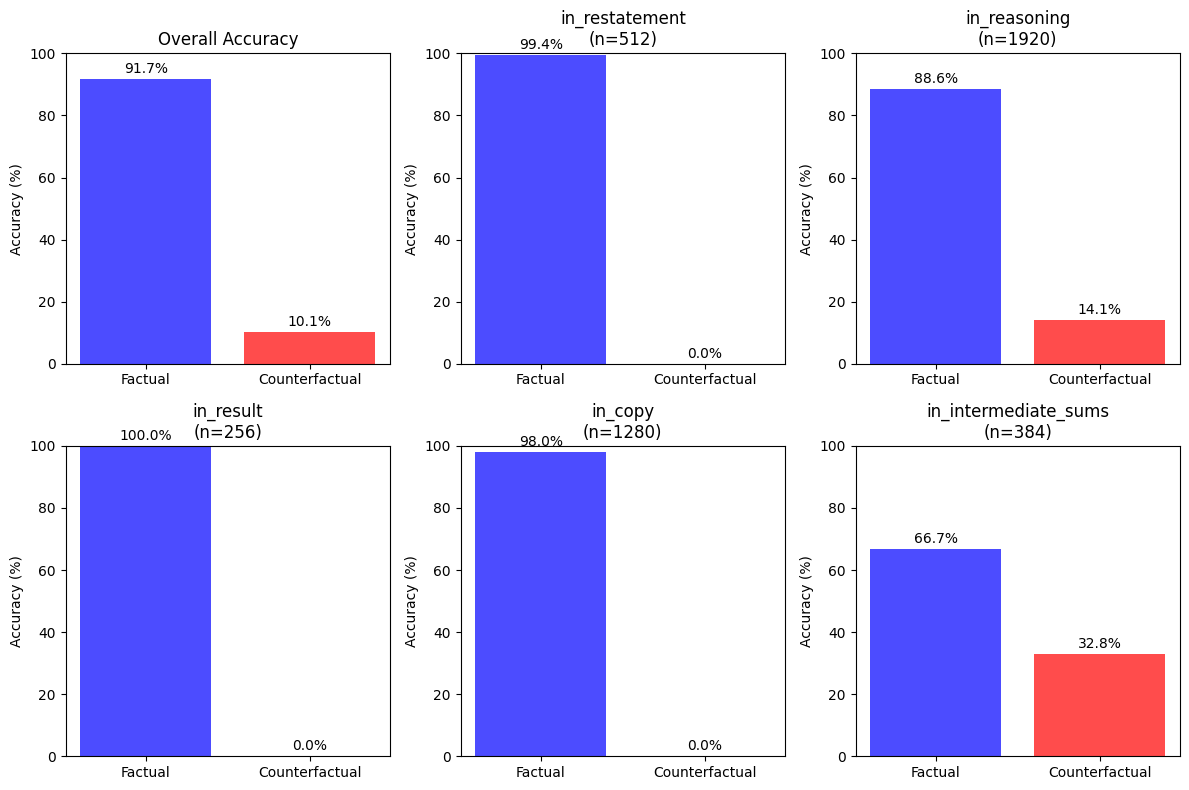


Detailed Statistics:
Overall - Factual: 91.74%, Counterfactual: 10.08%
in_restatement - Factual: 99.41%, Counterfactual: 0.00% (n=512)
in_reasoning - Factual: 88.59%, Counterfactual: 14.11% (n=1920)
in_result - Factual: 100.00%, Counterfactual: 0.00% (n=256)
in_copy - Factual: 97.97%, Counterfactual: 0.00% (n=1280)
in_intermediate_sums - Factual: 66.67%, Counterfactual: 32.81% (n=384)


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

df = accuracy_results

# Plot 1: Overall factual accuracy
plt.figure(figsize=(12, 8))

# Overall accuracy
overall_factual_acc = df['is_factual'].mean() * 100
overall_counterfactual_acc = df['is_counterfactual'].mean() * 100

plt.subplot(2, 3, 1)
plt.bar(['Factual', 'Counterfactual'], [overall_factual_acc, overall_counterfactual_acc], 
        color=['blue', 'red'], alpha=0.7)
plt.title('Overall Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add percentage labels on bars
plt.text(0, overall_factual_acc + 2, f'{overall_factual_acc:.1f}%', ha='center')
plt.text(1, overall_counterfactual_acc + 2, f'{overall_counterfactual_acc:.1f}%', ha='center')

# Filter columns to analyze
filter_columns = ['in_restatement', 'in_reasoning', 'in_result', 'in_copy', 'in_intermediate_sums']

# Plot accuracy for each filter
for i, col in enumerate(filter_columns, 2):
    if col in df.columns:
        # Filter data where the column is True
        filtered_df = df[df[col] == True]
        
        if len(filtered_df) > 0:
            factual_acc = filtered_df['is_factual'].mean() * 100
            counterfactual_acc = filtered_df['is_counterfactual'].mean() * 100
            
            plt.subplot(2, 3, i)
            plt.bar(['Factual', 'Counterfactual'], [factual_acc, counterfactual_acc], 
                    color=['blue', 'red'], alpha=0.7)
            plt.title(f'{col}\n(n={len(filtered_df)})')
            plt.ylabel('Accuracy (%)')
            plt.ylim(0, 100)
            
            # Add percentage labels on bars
            plt.text(0, factual_acc + 2, f'{factual_acc:.1f}%', ha='center')
            plt.text(1, counterfactual_acc + 2, f'{counterfactual_acc:.1f}%', ha='center')
        else:
            plt.subplot(2, 3, i)
            plt.text(0.5, 0.5, 'No data', ha='center', va='center', transform=plt.gca().transAxes)
            plt.title(f'{col}\n(n=0)')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print(f"Overall - Factual: {overall_factual_acc:.2f}%, Counterfactual: {overall_counterfactual_acc:.2f}%")

for col in filter_columns:
    if col in df.columns:
        filtered_df = df[df[col] == True]
        if len(filtered_df) > 0:
            factual_acc = filtered_df['is_factual'].mean() * 100
            counterfactual_acc = filtered_df['is_counterfactual'].mean() * 100
            print(f"{col} - Factual: {factual_acc:.2f}%, Counterfactual: {counterfactual_acc:.2f}% (n={len(filtered_df)})")
        else:
            print(f"{col} - No data available")


In [23]:
def has_wait(generated_text):
    return "wait" in generated_text.lower()

def has_wait_before_answer(generated_text, answer):
    return generated_text.split(answer)[0].lower().count("wait") > 0

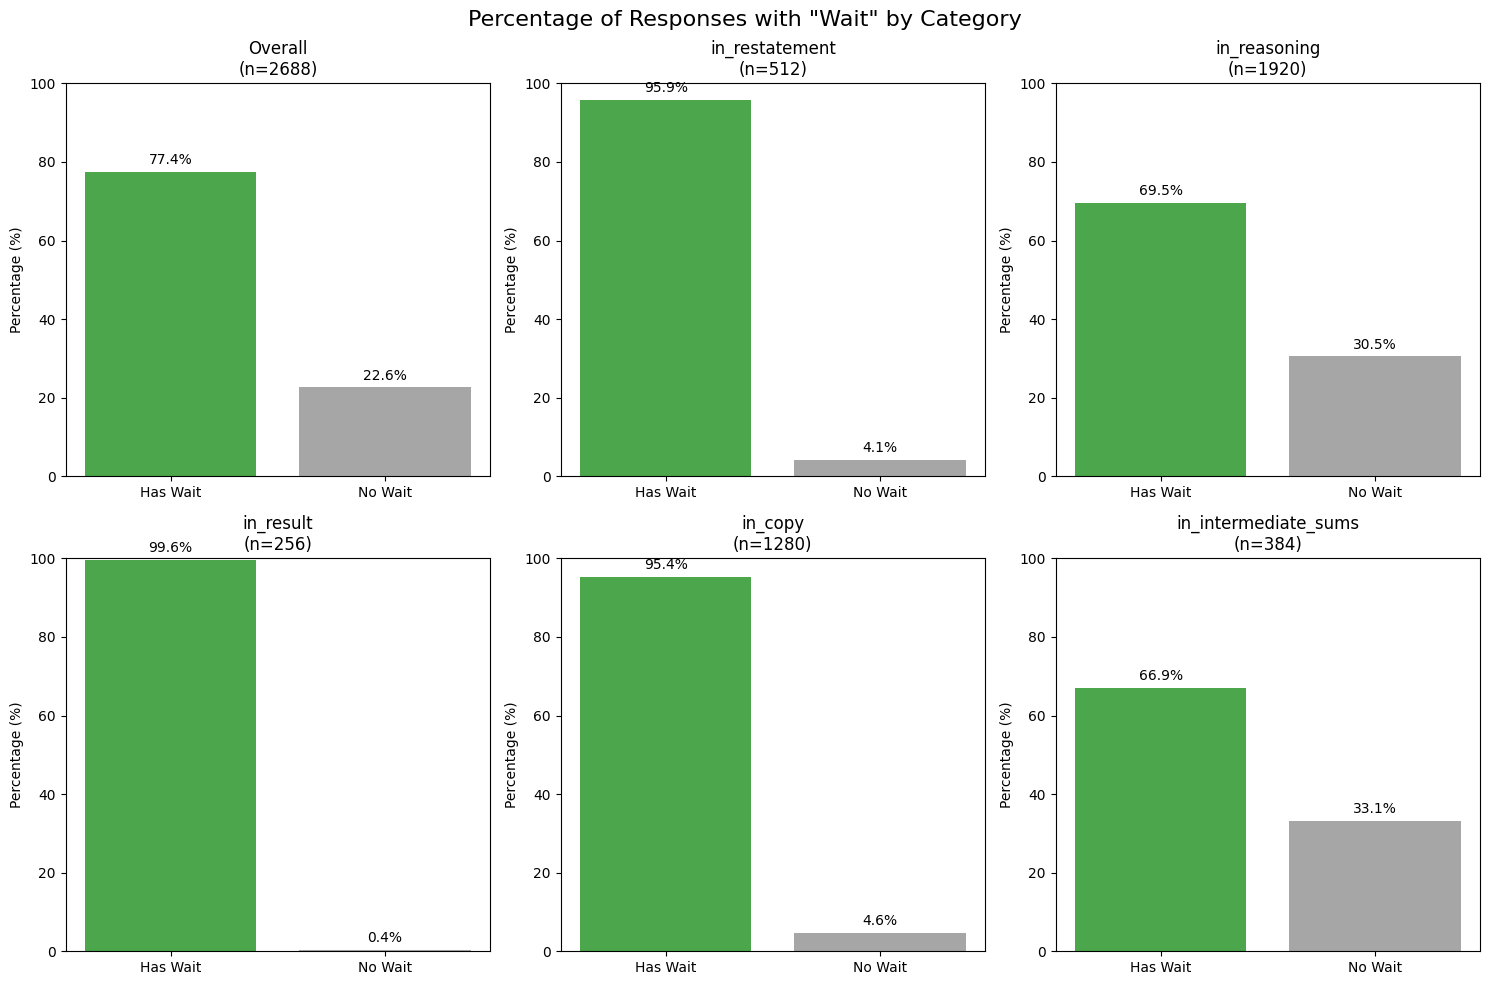

/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]


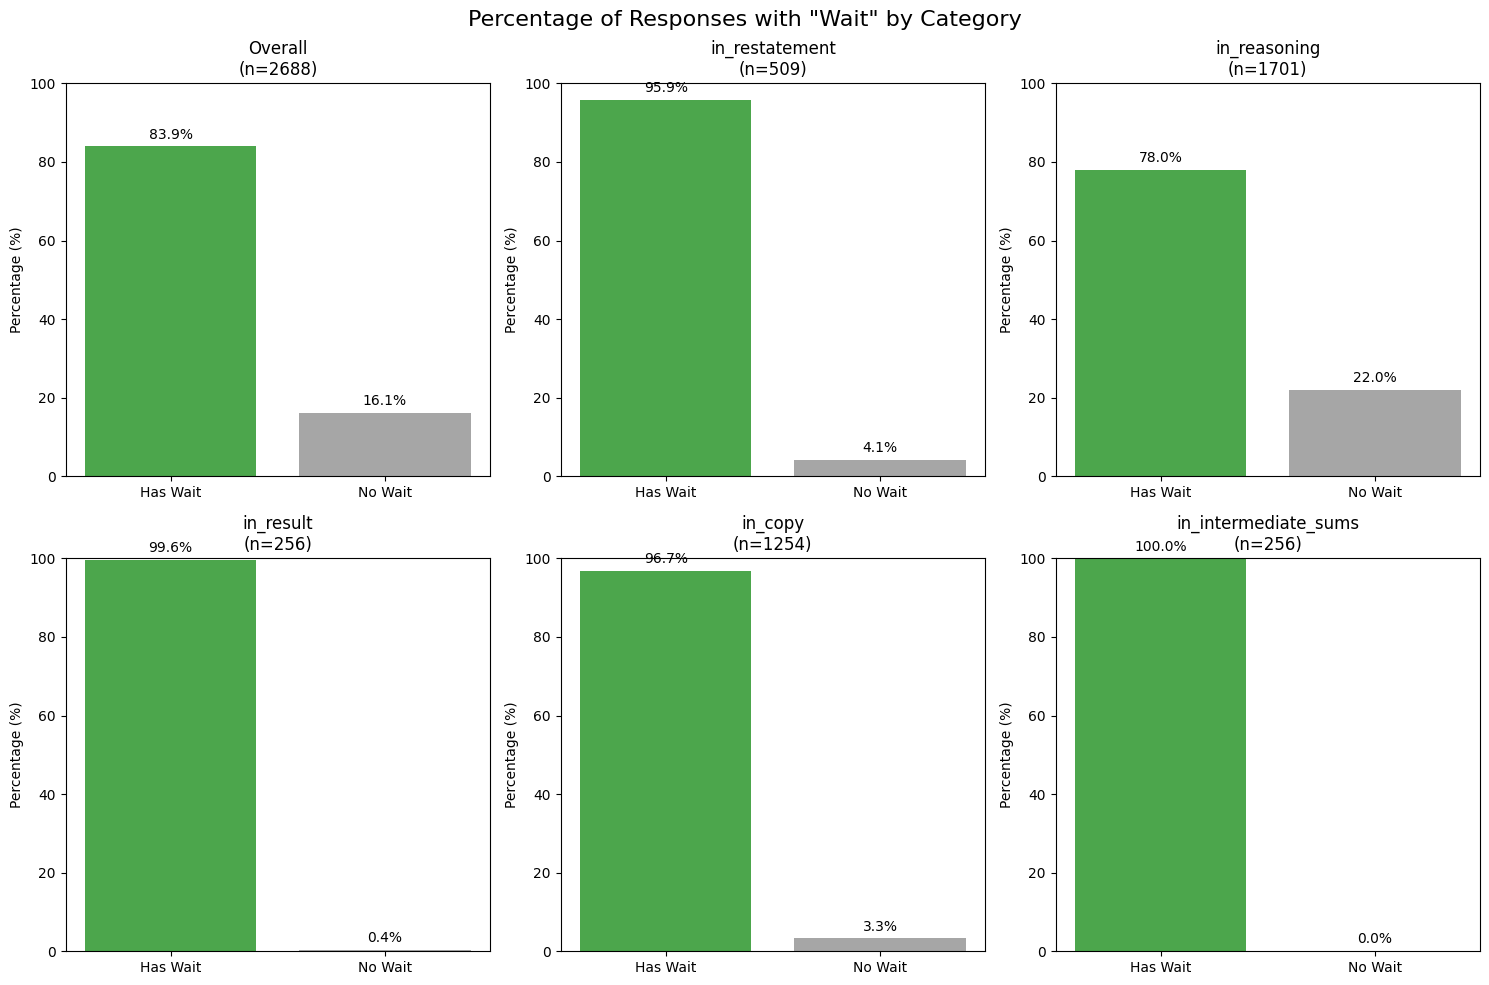

/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]


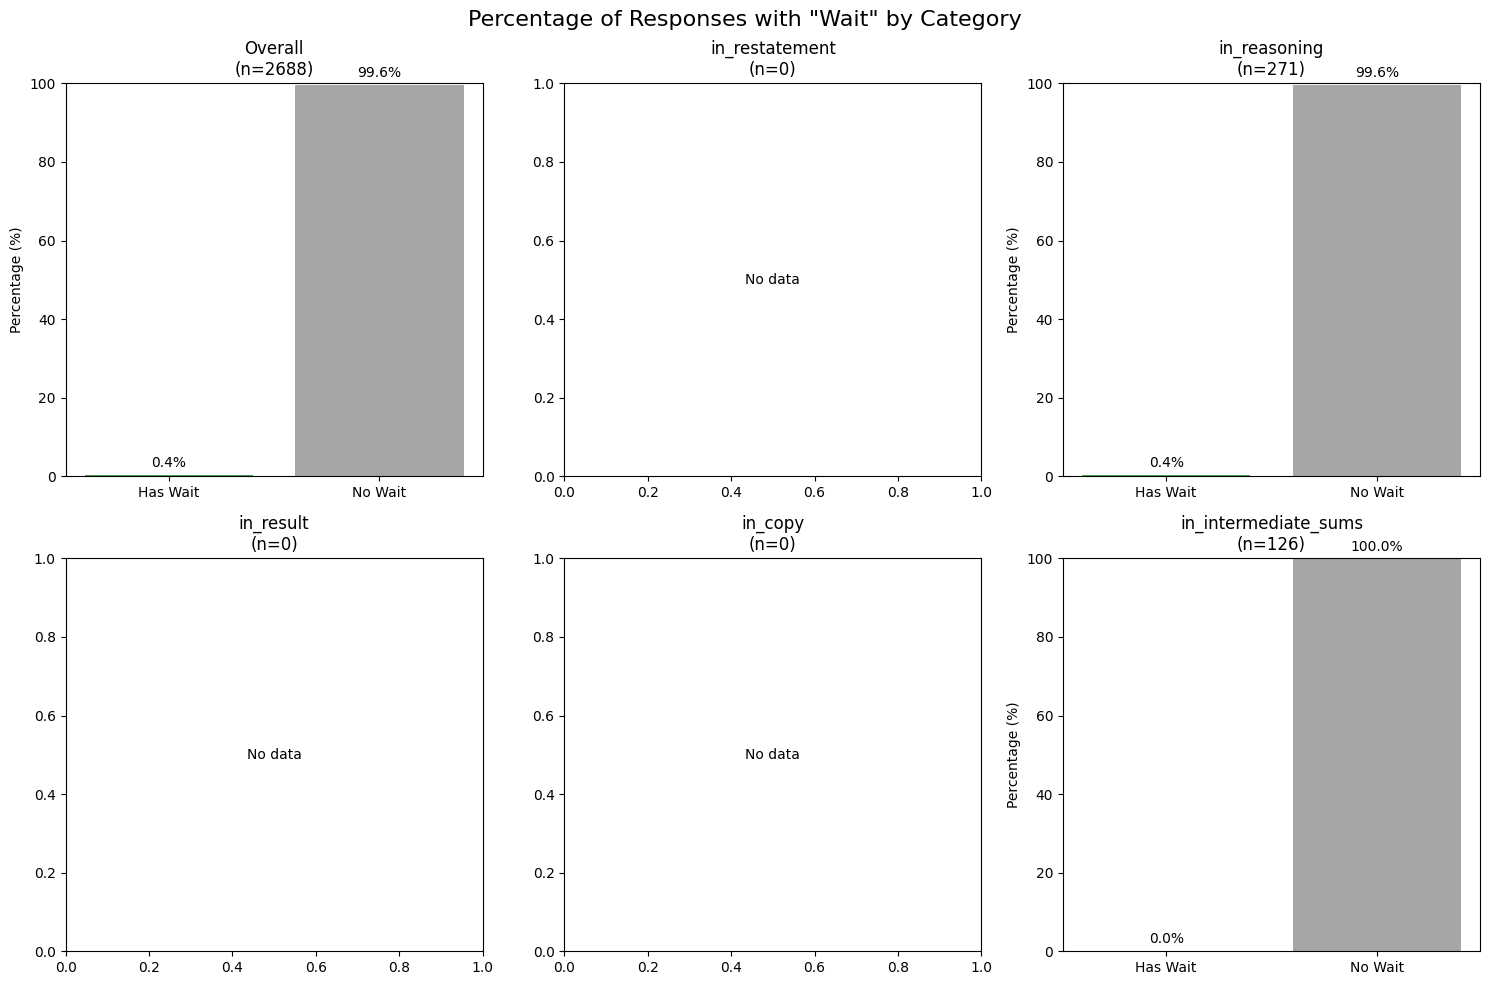

/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]
/tmp/ipykernel_3569571/482085866.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = df[accuracy_results[col] == True]


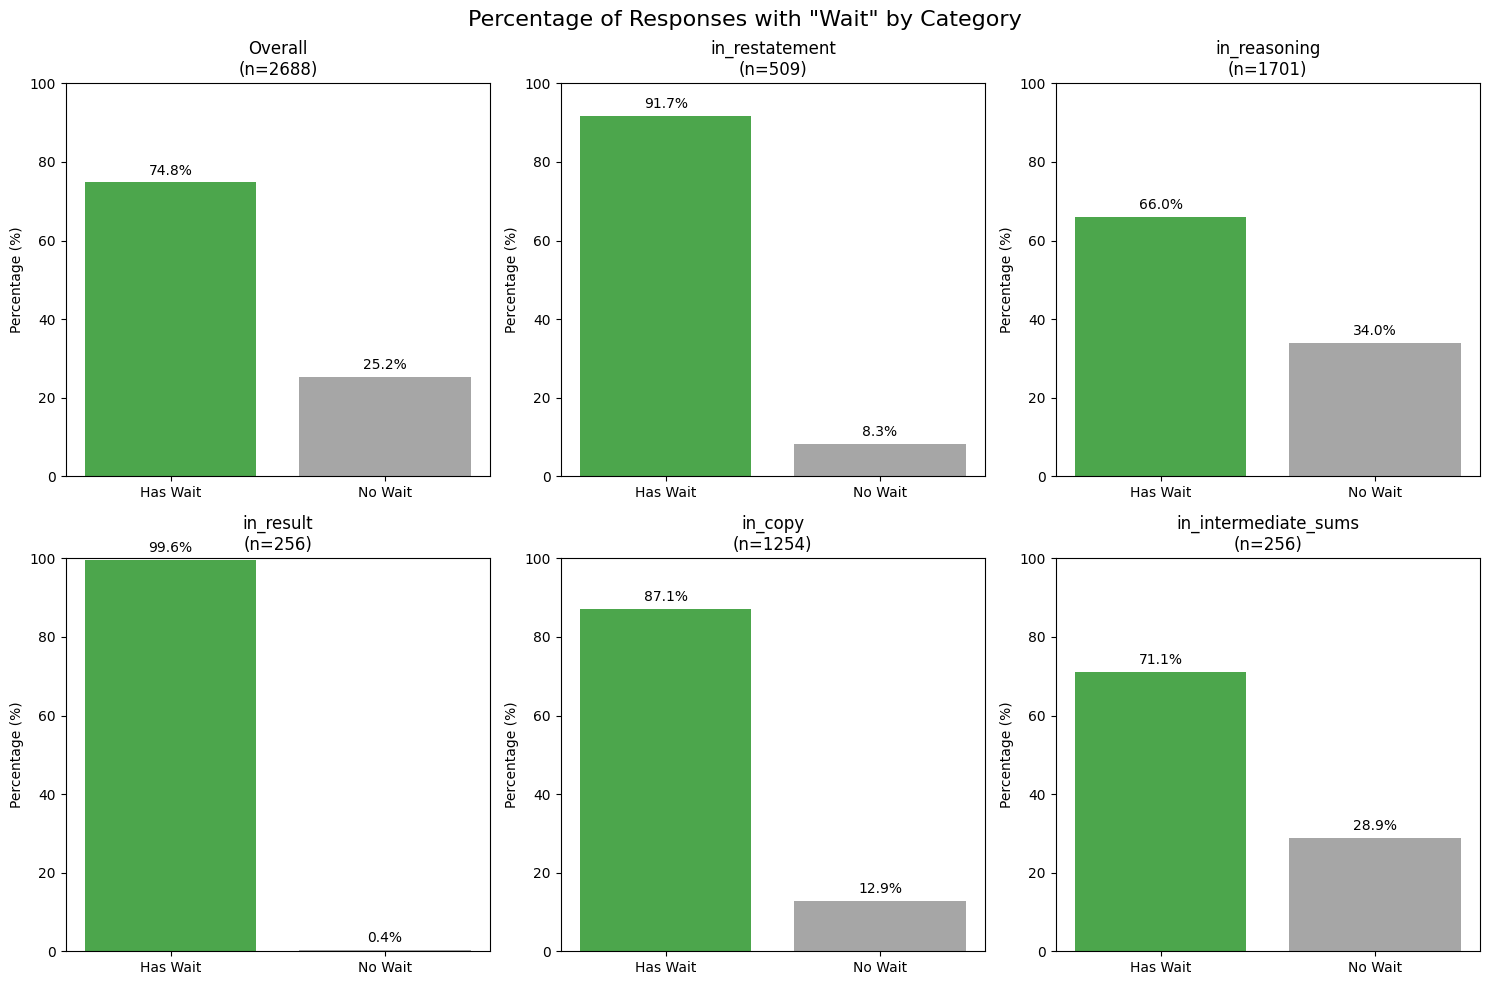

In [24]:
# Add wait analysis columns to accuracy_results
accuracy_results['has_wait'] = accuracy_results['generated_text'].apply(has_wait)
accuracy_results['has_wait_before_answer'] = accuracy_results.apply(
    lambda row: has_wait_before_answer(row['generated_text'], str(row['base_sum'])), axis=1
)

def plot_ratio(df, column='has_wait'):

    # Plot wait analysis
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Percentage of Responses with "Wait" by Category', fontsize=16)

    # Overall statistics
    overall_wait_pct = df[column].mean() * 100

    # Plot overall
    plt.subplot(2, 3, 1)
    plt.bar(['Has Wait', 'No Wait'], 
            [overall_wait_pct, 100 - overall_wait_pct], 
            color=['green', 'gray'], alpha=0.7)
    plt.title(f'Overall\n(n={len(accuracy_results)})')
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 100)
    plt.text(0, overall_wait_pct + 2, f'{overall_wait_pct:.1f}%', ha='center')
    plt.text(1, (100 - overall_wait_pct) + 2, f'{100 - overall_wait_pct:.1f}%', ha='center')

    # Plot for each filter column
    for i, col in enumerate(filter_columns, 2):
        if col in accuracy_results.columns:
            filtered_df = df[accuracy_results[col] == True]
            if len(filtered_df) > 0:
                wait_pct = filtered_df[column].mean() * 100
                
                plt.subplot(2, 3, i)
                plt.bar(['Has Wait', 'No Wait'], 
                        [wait_pct, 100 - wait_pct], 
                        color=['green', 'gray'], alpha=0.7)
                plt.title(f'{col}\n(n={len(filtered_df)})')
                plt.ylabel('Percentage (%)')
                plt.ylim(0, 100)
                
                # Add percentage labels on bars
                plt.text(0, wait_pct + 2, f'{wait_pct:.1f}%', ha='center')
                plt.text(1, (100 - wait_pct) + 2, f'{100 - wait_pct:.1f}%', ha='center')
            else:
                plt.subplot(2, 3, i)
                plt.text(0.5, 0.5, 'No data', ha='center', va='center', transform=plt.gca().transAxes)
                plt.title(f'{col}\n(n=0)')

    plt.tight_layout()
    plt.show()

plot_ratio(accuracy_results)
plot_ratio(accuracy_results[accuracy_results['is_factual'] == True])
plot_ratio(accuracy_results[accuracy_results['is_counterfactual'] == True])
plot_ratio(accuracy_results[accuracy_results['is_factual'] == True], column='has_wait_before_answer')
